<a href="https://colab.research.google.com/github/SupremeOne3000/CI_project/blob/main/Irrigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

# 1. Upload the original dataset
print("Please upload your original Smart_Farming_Crop_Yield_2024.csv file:")
uploaded = files.upload()

# 2. Read the uploaded file
df = pd.read_csv("Smart_Farming_Crop_Yield_2024.csv")

# 3. Filter columns and drop missing data
columns_to_keep = ['farm_id', 'temperature_C', 'humidity_%', 'soil_moisture_%']
df_cleaned = df[columns_to_keep].dropna().copy()

# 4. Synthesize the target column (1 = Pump ON, 0 = Pump OFF)
df_cleaned['irrigation_needed'] = (
    (df_cleaned['soil_moisture_%'] < 30) |
    ((df_cleaned['temperature_C'] > 32) & (df_cleaned['humidity_%'] < 50))
).astype(int)

# 5. Save the new edited dataset inside Colab
output_filename = "Cleaned_Irrigation_Data_2024.csv"
df_cleaned.to_csv(output_filename, index=False)
print(f"\nData successfully cleaned and saved as {output_filename}!")

# 6. Download the edited file directly to your computer
files.download(output_filename)

Please upload your original Smart_Farming_Crop_Yield_2024.csv file:


Saving Smart_Farming_Crop_Yield_2024.csv to Smart_Farming_Crop_Yield_2024.csv

Data successfully cleaned and saved as Cleaned_Irrigation_Data_2024.csv!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Please upload your Cleaned_Irrigation_Data_2024.csv file:


Saving Cleaned_Irrigation_Data_2024.csv to Cleaned_Irrigation_Data_2024 (1).csv

--- Training Random Forest ---
Random Forest Accuracy: 1.0000

--- Training Deep Learning MLP ---
Epoch 1, Loss: 0.6434
Epoch 2, Loss: 0.5016
Epoch 3, Loss: 0.3570
Epoch 4, Loss: 0.2251
Epoch 5, Loss: 0.1698
Epoch 6, Loss: 0.1760
Epoch 7, Loss: 0.1375
Epoch 8, Loss: 0.1345
Epoch 9, Loss: 0.1231
Epoch 10, Loss: 0.1383
Epoch 11, Loss: 0.1538
Epoch 12, Loss: 0.1296
Epoch 13, Loss: 0.1135
Epoch 14, Loss: 0.1235
Epoch 15, Loss: 0.1265
Epoch 16, Loss: 0.1230
Epoch 17, Loss: 0.1467
Epoch 18, Loss: 0.1396
Epoch 19, Loss: 0.1292
Epoch 20, Loss: 0.0936
Epoch 21, Loss: 0.1008
Epoch 22, Loss: 0.1173
Epoch 23, Loss: 0.1080
Epoch 24, Loss: 0.1229
Epoch 25, Loss: 0.1467
Epoch 26, Loss: 0.1282
Epoch 27, Loss: 0.1155
Epoch 28, Loss: 0.1066
Epoch 29, Loss: 0.1066
Epoch 30, Loss: 0.0958


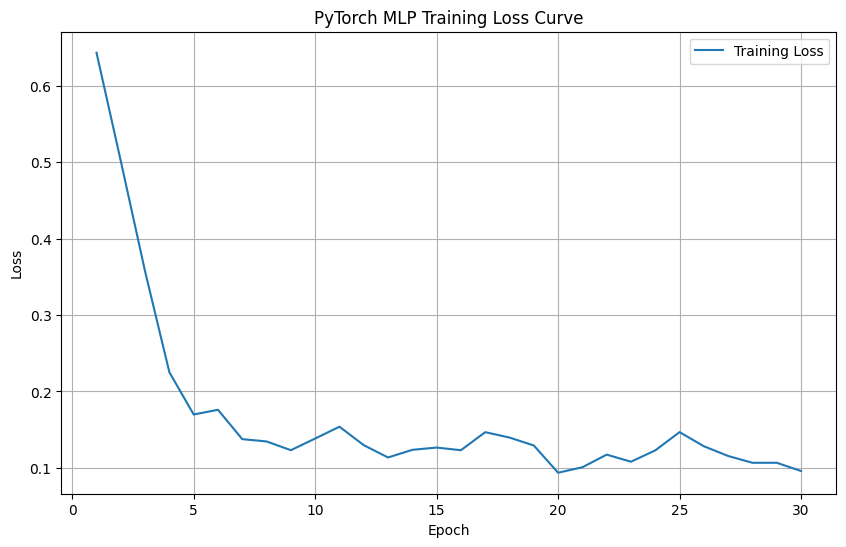

Deep Learning Accuracy: 0.9800


In [2]:
from google.colab import files
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# 1. Upload the CLEANED data
print("Please upload your Cleaned_Irrigation_Data_2024.csv file:")
uploaded = files.upload()

# 2. Load the data (no extra cleaning needed since it's already prepped)
df = pd.read_csv("Cleaned_Irrigation_Data_2024.csv")

X = df[['temperature_C', 'humidity_%', 'soil_moisture_%']]
y = df['irrigation_needed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train Classical ML: Random Forest
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# 4. Train Deep Learning: PyTorch MLP
print("\n--- Training Deep Learning MLP ---")
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

class IrrigationClassifier(nn.Module):
    def __init__(self):
        super(IrrigationClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

dl_model = IrrigationClassifier()
optimizer = torch.optim.Adam(dl_model.parameters(), lr=0.005)
criterion = nn.BCELoss()

# List to store loss values
training_losses = []

for epoch in range(30):
    dl_model.train()
    current_epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = dl_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        current_epoch_loss += loss.item()
    avg_epoch_loss = current_epoch_loss / len(train_loader)
    training_losses.append(avg_epoch_loss) # Average loss for the epoch
    print(f"Epoch {epoch+1}, Loss: {avg_epoch_loss:.4f}")

# Plotting the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), training_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch MLP Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

dl_model.eval()
with torch.no_grad():
    y_pred_dl = (dl_model(X_test_t) >= 0.5).int().squeeze().numpy()

print(f"Deep Learning Accuracy: {accuracy_score(y_test, y_pred_dl):.4f}")